# **Batch gradient descent**


# **Import Libraries**

In [14]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import SGDRegressor

## **Load Builtin Dataset**

In [15]:
X, y = load_diabetes(return_X_y=True)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (442, 10)
Target shape: (442,)


## **Train_test_split**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (353, 10)
Testing samples: (89, 10)


## **Train Gradient Descent Model (Scikit-learn)**

In [17]:
sgd = SGDRegressor(
    max_iter=1000,
    learning_rate='constant',
    eta0=0.01,
    random_state=42
)

sgd.fit(X_train, y_train)

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


### **Model Parameters**

In [18]:
print("Intercept:", sgd.intercept_)
print("Coefficients:", sgd.coef_)

Intercept: [153.91717986]
Coefficients: [  47.29895975  -94.40544491  390.21533966  270.39101652    2.19125838
  -52.79847852 -182.43159735  124.43343169  352.71509191  124.86506026]


- The intercept represents the base prediction when all features are zero.
- The coefficients represent the effect of each feature on the prediction.

In [19]:
y_pred = sgd.predict(X_test)

In [20]:
score = r2_score(y_test, y_pred)
print("R2 Score:", score)

R2 Score: 0.44411870462940406


- R² measures how well the model explains variance in the target variable.

- Closer to 1 → better model
- Closer to 0 → weak model

### **Compare with Standard Linear Regression**

In [21]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Linear Regression R2: 0.439933866156897


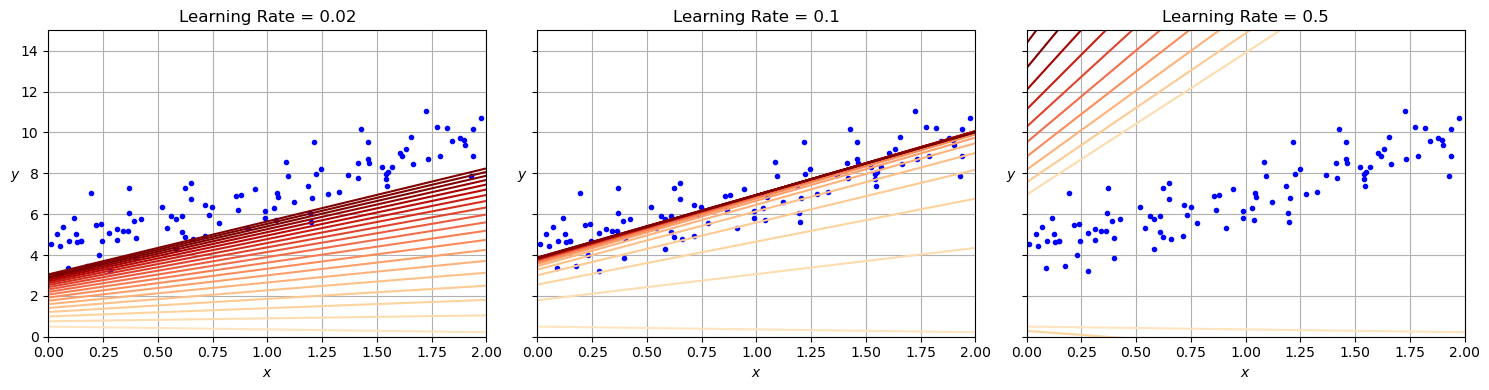

In [22]:
# Extre code 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Simple sample data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Add bias term
X_b = np.c_[np.ones((100, 1)), X]

# New points for drawing prediction lines
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    n_epochs = 1000
    n_shown = 20
    theta_path = []

    plt.plot(X, y, "b.")

    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)

        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)

    plt.xlabel("$x$")
    plt.ylabel("$y$", rotation=0)
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(f"Learning Rate = {eta}")

    return theta_path

# Random initialization
np.random.seed(42)
theta = np.random.randn(2, 1)

# Plot for different learning rates
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plot_gradient_descent(theta, eta=0.02)

plt.subplot(1, 3, 2)
plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])

plt.subplot(1, 3, 3)
plot_gradient_descent(theta, eta=0.5)
plt.gca().axes.yaxis.set_ticklabels([])

plt.tight_layout()
plt.show()


- **Learning Rate = 0.02**
The model learns very slowly. The updates are small, so convergence takes more time.

- **Learning Rate = 0.1**
This is a good learning rate. The model converges faster and reaches the optimal line smoothly.

- **Learning Rate = 0.5**
The updates are too large. The model may overshoot the optimal solution and become unstable.The learning rate is a very important hyperparameter in Gradient Descent.
 A very small learning rate makes learning slow, while a very large learning rate can make training unstable.
 A moderate learning rate usually gives the best results.

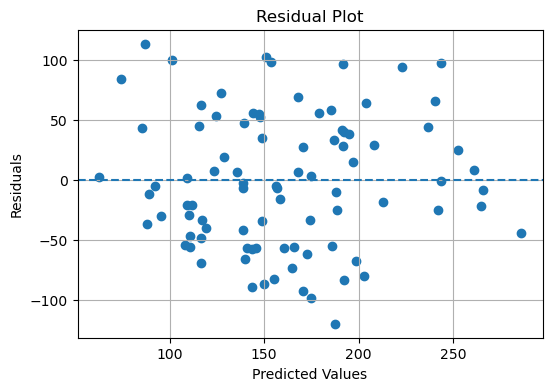

In [24]:
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid()
plt.show()

### **Make our own Class**

In [9]:
class GDRegressor:
    
    def __init__(self,learning_rate=0.01,epochs=100):
        
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self,X_train,y_train):
        # init your coefs
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        
        for i in range(self.epochs):
            # update all the coef and the intercept
            y_hat = np.dot(X_train,self.coef_) + self.intercept_
            #print("Shape of y_hat",y_hat.shape)
            intercept_der = -2 * np.mean(y_train - y_hat)
            self.intercept_ = self.intercept_ - (self.lr * intercept_der)
            
            coef_der = -2 * np.dot((y_train - y_hat),X_train)/X_train.shape[0]
            self.coef_ = self.coef_ - (self.lr * coef_der)
        
        print(self.intercept_,self.coef_)
    
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [10]:
gdr = GDRegressor(epochs=1000,learning_rate=0.1)

In [11]:
gdr.fit(X_train,y_train)

151.94042847773682 [  62.27835432  -24.14017912  262.40285385  192.20751489   39.48809013
   10.26886323 -142.50597903  124.33312557  244.33510843  119.34350233]


In [12]:
y_pred = gdr.predict(X_test)

In [13]:
r2_score(y_test,y_pred)

0.3971698388048742